In [1]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 41.4 MB/s eta 0:00:00


In [2]:
# ============================================
# PART 1: IMPORT LIBRARIES
# ============================================

!pip install rdkit

from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
import re
import joblib

# Machine Learning Libraries
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

import xgboost as xgb
import lightgbm as lgb

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# ============================================
# PART 2: UPLOAD & LOAD QSAR DATASET
# ============================================

print("="*50)
print("📤 STEP 1: Upload QSAR Dataset")
print("="*50)
print("\nUpload your QSAR dataset file:")
print("  📁 qsar_cox2_ic50.csv")

uploaded_qsar = files.upload()
qsar_filename = list(uploaded_qsar.keys())[0]
print(f"\n✅ File uploaded: {qsar_filename}")

qsar_data = pd.read_csv(qsar_filename, sep=';', encoding='latin-1')
print(f"✅ QSAR Dataset loaded: {qsar_data.shape}")


📤 STEP 1: Upload QSAR Dataset

Upload your QSAR dataset file:
  📁 qsar_cox2_ic50.csv


Saving qsar_cox2_ic50.csv to qsar_cox2_ic50.csv

✅ File uploaded: qsar_cox2_ic50.csv
✅ QSAR Dataset loaded: (15314, 48)


In [4]:
# ============================================
# PART 3: INITIAL EXPLORATION
# ============================================

print("\n" + "="*50)
print("📊 STEP 2: Initial Exploration")
print("="*50)

print(f"\n📊 QSAR Dataset (COX-2)")
print("-" * 40)
print(f"Shape: {qsar_data.shape}")
print(f"Columns ({len(qsar_data.columns)}):")
print(qsar_data.columns.tolist()[:10], "...")
print(f"\nFirst 3 rows:")
display(qsar_data.head(3))

# Check target
print("\n" + "="*50)
print("🎯 STEP 3: Target Columns Check")
print("="*50)

print("\n🔬 QSAR Target (pIC50):")
if 'pChEMBL Value' in qsar_data.columns:
    print(f"  ✅ Found: 'pChEMBL Value'")
    print(f"  Values: {qsar_data['pChEMBL Value'].min():.2f} to {qsar_data['pChEMBL Value'].max():.2f}")
    print(f"  Missing: {qsar_data['pChEMBL Value'].isnull().sum()}")
else:
    print("  ❌ 'pChEMBL Value' not found")

print("\n🧬 SMILES Column:")
if 'Smiles' in qsar_data.columns:
    print(f"  ✅ Found: 'Smiles'")
else:
    print("  ❌ No 'Smiles' column found")


📊 STEP 2: Initial Exploration

📊 QSAR Dataset (COX-2)
----------------------------------------
Shape: (15314, 48)
Columns (48):
['Molecule ChEMBL ID', 'Molecule Name', 'Molecule Max Phase', 'Molecular Weight', '#RO5 Violations', 'AlogP', 'Compound Key', 'Smiles', 'Standard Type', 'Standard Relation'] ...

First 3 rows:


,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL144840,NaN,NaN,196.27,0.0,2.72,37,CCC(=O)Oc1ccccc1SC,IC50,'>',...,CHEMBL1131194,1,Scientific Literature,J Med Chem,1998.0,NaN,NaN,NaN,NaN,1000.00
1,CHEMBL18264,NaN,NaN,350.34,0.0,2.84,MF-tricyclic,CS(=O)(=O)c1ccc(C2=C(c3ccc(F)c(F)c3)C(=O)OC2)cc1,IC50,'=',...,CHEMBL1147594,1,Scientific Literature,Bioorg Med Chem Lett,2004.0,NaN,NaN,NaN,NaN,0.48
2,CHEMBL289484,NaN,NaN,404.88,0.0,3.77,92,CCOC(=O)c1cn(-c2ccc(S(C)(=O)=O)cc2)c(-c2ccc(Cl...,IC50,'=',...,CHEMBL1134614,1,Scientific Literature,J Med Chem,2001.0,NaN,NaN,NaN,NaN,5.24



🎯 STEP 3: Target Columns Check

🔬 QSAR Target (pIC50):
  ✅ Found: 'pChEMBL Value'
  Values: 4.00 to 10.70
  Missing: 9025

🧬 SMILES Column:
  ✅ Found: 'Smiles'


In [5]:
# ============================================
# PART 4: DATA QUALITY CHECK
# ============================================

print("\n" + "="*50)
print("🔍 STEP 4: Data Quality Check")
print("="*50)

print(f"\n📊 Missing Values: {qsar_data.isnull().sum().sum()} total missing")

qsar_dups = qsar_data.duplicated().sum() if 'Smiles' in qsar_data.columns else 0
print(f"🔁 Duplicates: {qsar_dups} duplicate rows")

def validate_smiles(smiles_list, n=500):
    valid = 0
    total = 0
    for s in smiles_list[:n]:
        if pd.notna(s) and isinstance(s, str):
            total += 1
            try:
                mol = Chem.MolFromSmiles(s)
                if mol:
                    valid += 1
            except:
                pass
    return valid, total

if 'Smiles' in qsar_data.columns:
    valid, total = validate_smiles(qsar_data['Smiles'], 500)
    print(f"🧪 Valid SMILES (first 500): {valid}/{total} valid ({valid/total*100:.1f}%)")


🔍 STEP 4: Data Quality Check

📊 Missing Values: 274591 total missing
🔁 Duplicates: 14 duplicate rows
🧪 Valid SMILES (first 500): 496/496 valid (100.0%)



📈 STEP 6: Target Distribution


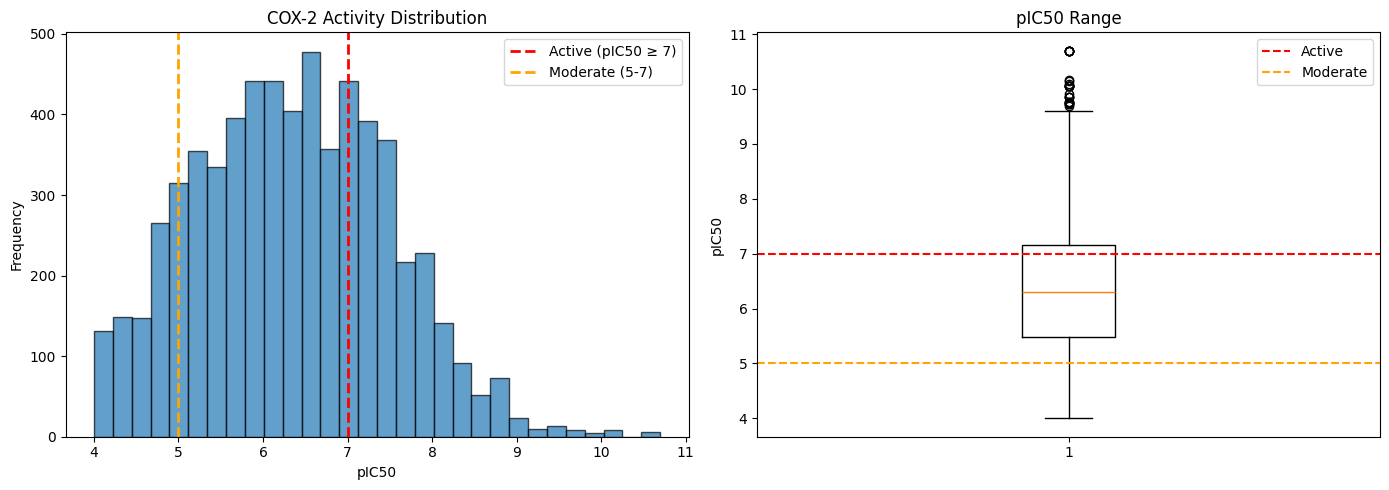

In [6]:
# ============================================
# PART 6: TARGET DISTRIBUTION VISUALIZATION
# ============================================

print("\n" + "="*50)
print("📈 STEP 6: Target Distribution")
print("="*50)

# QSAR pIC50 Distribution
if 'pChEMBL Value' in qsar_data.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    axes[0].hist(qsar_data['pChEMBL Value'].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0].axvline(x=7, color='red', linestyle='--', linewidth=2, label='Active (pIC50 ≥ 7)')
    axes[0].axvline(x=5, color='orange', linestyle='--', linewidth=2, label='Moderate (5-7)')
    axes[0].set_xlabel('pIC50')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('COX-2 Activity Distribution')
    axes[0].legend()

    # Box plot
    axes[1].boxplot(qsar_data['pChEMBL Value'].dropna())
    axes[1].set_ylabel('pIC50')
    axes[1].set_title('pIC50 Range')
    axes[1].axhline(y=7, color='red', linestyle='--', label='Active')
    axes[1].axhline(y=5, color='orange', linestyle='--', label='Moderate')
    axes[1].legend()

    plt.tight_layout()
    plt.show()